# 1. Load the clean data

In [199]:
import numpy as np
import pandas as pd
data_clean=pd.read_csv("cleaned_dataset.csv")
data_clean

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,FireplaceYN_missing,PoolPrivateYN_missing,NewConstructionYN_missing,PropertyType_CommercialLease,PropertyType_CommercialSale,PropertyType_Land,PropertyType_ManufacturedInPark,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease
0,1,0,6500.0,33.475311,-117.708995,3870.0,MB - Monarch Beach,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
1,1,0,1800000.0,33.899427,-117.977995,7740.0,83 - Fullerton,Orange,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
2,1,0,1200000.0,34.095980,-118.221993,4697.0,680 - Mount Washington,Los Angeles,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
3,1,1,3200.0,33.773119,-116.343788,1581.0,324 - East Palm Desert,Riverside,2.0,Condominium,...,0,0,0,False,False,False,False,False,False,True
4,1,0,1425000.0,33.884526,-117.778002,7500.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203272,1,0,865000.0,34.242304,-116.802871,868586.4,BBC - Big Bear City,San Bernardino,2.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False
203273,1,1,4000.0,33.701018,-116.292460,7405.0,313 - La Quinta South of HWY 111,Riverside,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,False,False,True
203274,0,0,127500.0,34.251991,-116.820227,1440.0,BBC - Big Bear City,San Bernardino,2.0,Unknown,...,1,0,1,False,False,False,True,False,False,False
203275,0,0,595000.0,37.824500,-122.281570,4389.0,Unknown,Alameda,3.0,SingleFamilyResidence,...,0,0,0,False,False,False,False,True,False,False


# 2. Test train valid split¶

In [200]:
X=7 # past 2 month
months = sorted(data_clean["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=data_clean[data_clean['date_ym'].isin(months[-X:-1])]
data_test=data_clean[data_clean['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

2026-04-01    15568
2026-05-01    15553
2026-03-01    15000
2025-12-01    13394
2026-02-01    11812
2026-01-01    10701
Name: date_ym, dtype: int64
2026-06-01    16410
Name: date_ym, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 82028 entries, 104839 to 186866
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ViewYN                           82028 non-null  int64  
 1   PoolPrivateYN                    82028 non-null  int64  
 2   ClosePrice                       82028 non-null  float64
 3   Latitude                         82028 non-null  float64
 4   Longitude                        82028 non-null  float64
 5   LivingArea                       82028 non-null  float64
 6   MLSAreaMajor                     82028 non-null  object 
 7   CountyOrParish                   82028 non-null  object 
 8   ParkingTotal                     82028 non-null  float64
 9   Pr

In [201]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16410 entries, 186867 to 203276
Data columns (total 37 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ViewYN                           16410 non-null  int64  
 1   PoolPrivateYN                    16410 non-null  int64  
 2   ClosePrice                       16410 non-null  float64
 3   Latitude                         16410 non-null  float64
 4   Longitude                        16410 non-null  float64
 5   LivingArea                       16410 non-null  float64
 6   MLSAreaMajor                     16410 non-null  object 
 7   CountyOrParish                   16410 non-null  object 
 8   ParkingTotal                     16410 non-null  float64
 9   PropertySubType                  16410 non-null  object 
 10  LotSizeAcres                     16410 non-null  float64
 11  YearBuilt                        16410 non-null  float64
 12  StreetNumber

In [202]:
cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# 保证列一致
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\AppData\Local\Temp\ipykernel_58812\3121791956.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\3121791956.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\3121791956.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [203]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

# 3. Train a Regression model and Evaluate the result

In [204]:
results = []

## 3.1 ElasticNet - Baseline model

In [207]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.086e+16, tolerance: 4.462e+12
  model = cd_fast.enet_coordinate_descent(


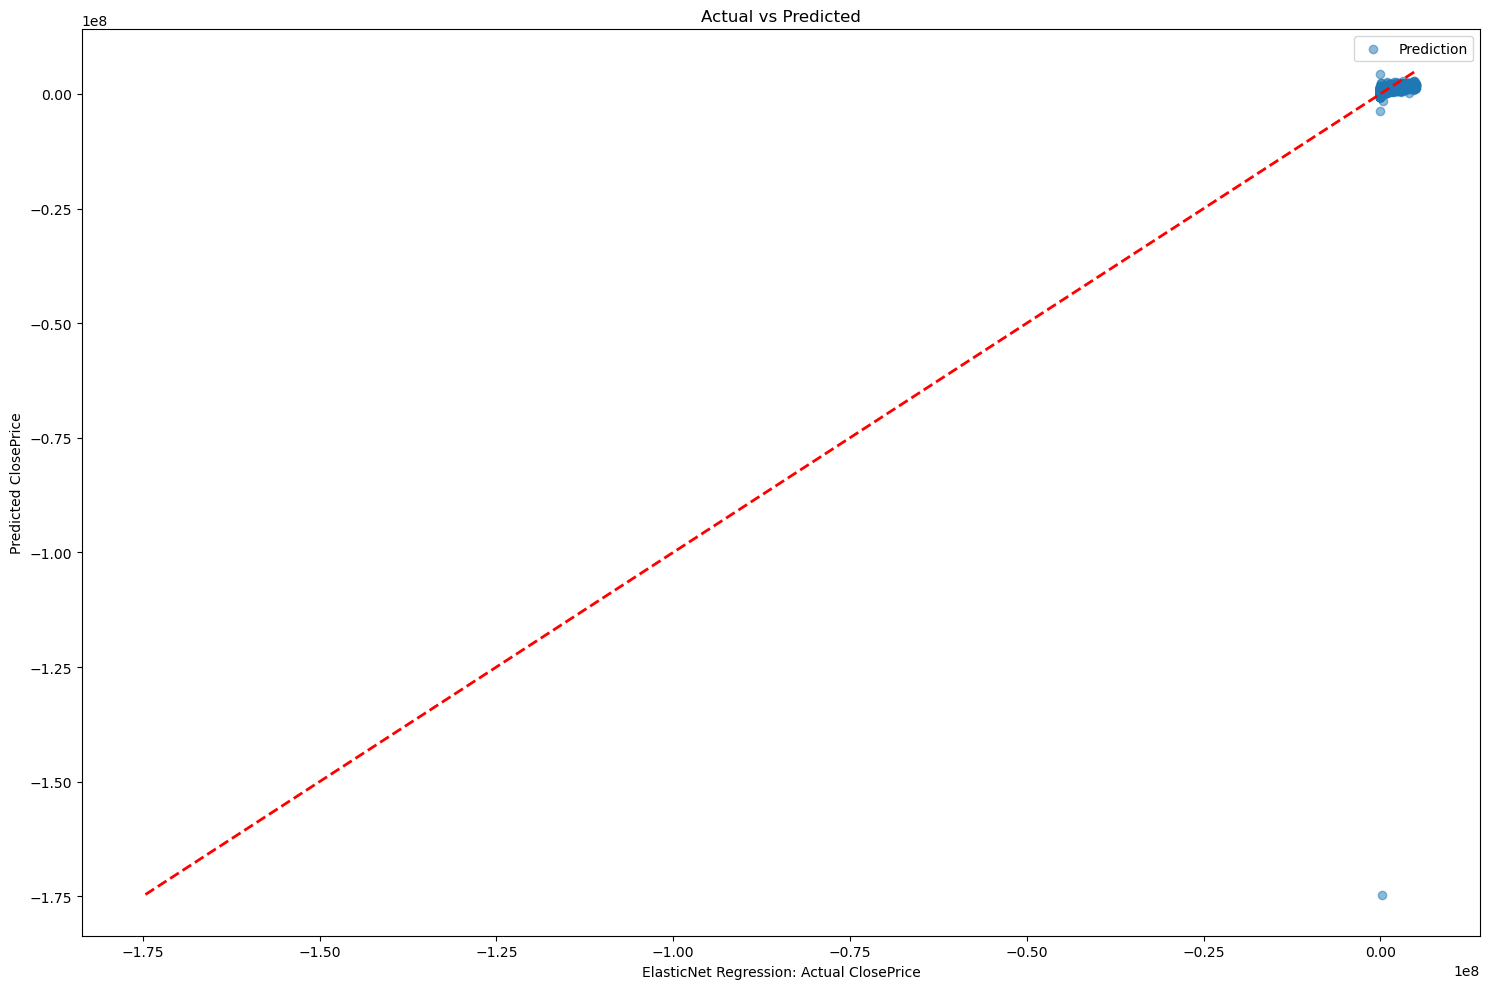

In [208]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("ElasticNet Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [209]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Ridge Regression- Baseline model",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 37.93%
MAPE : 16.0130
R²   : -2.7725
MAE  : 331324.0030
MSE  : 2105696958753.1301
RMSE : 1451101.9808


## 3.2 Decision Tree Regressor

In [217]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = DecisionTreeRegressor(max_depth=10,random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

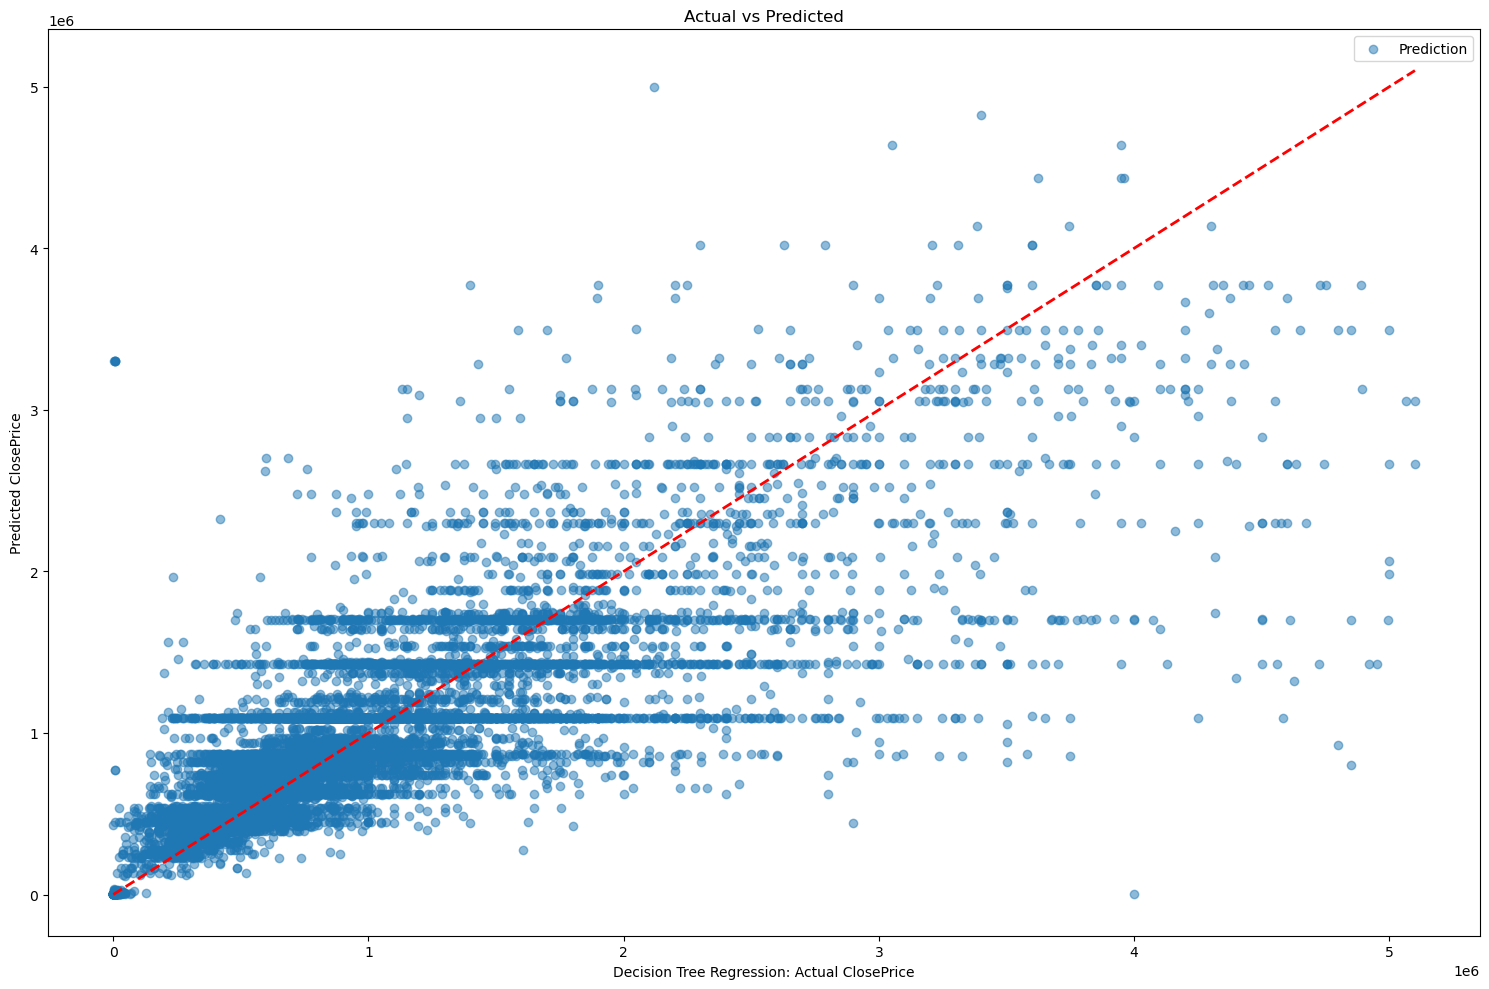

In [218]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Decision Tree Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [219]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Decision Tree Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 19.60%
MAPE : 0.5483
R²   : 0.7208
MAE  : 215893.4287
MSE  : 155830355445.6032
RMSE : 394753.5376


In [220]:
print(model.score(X_train, y_train))

0.7651456904065264


### Feature importance

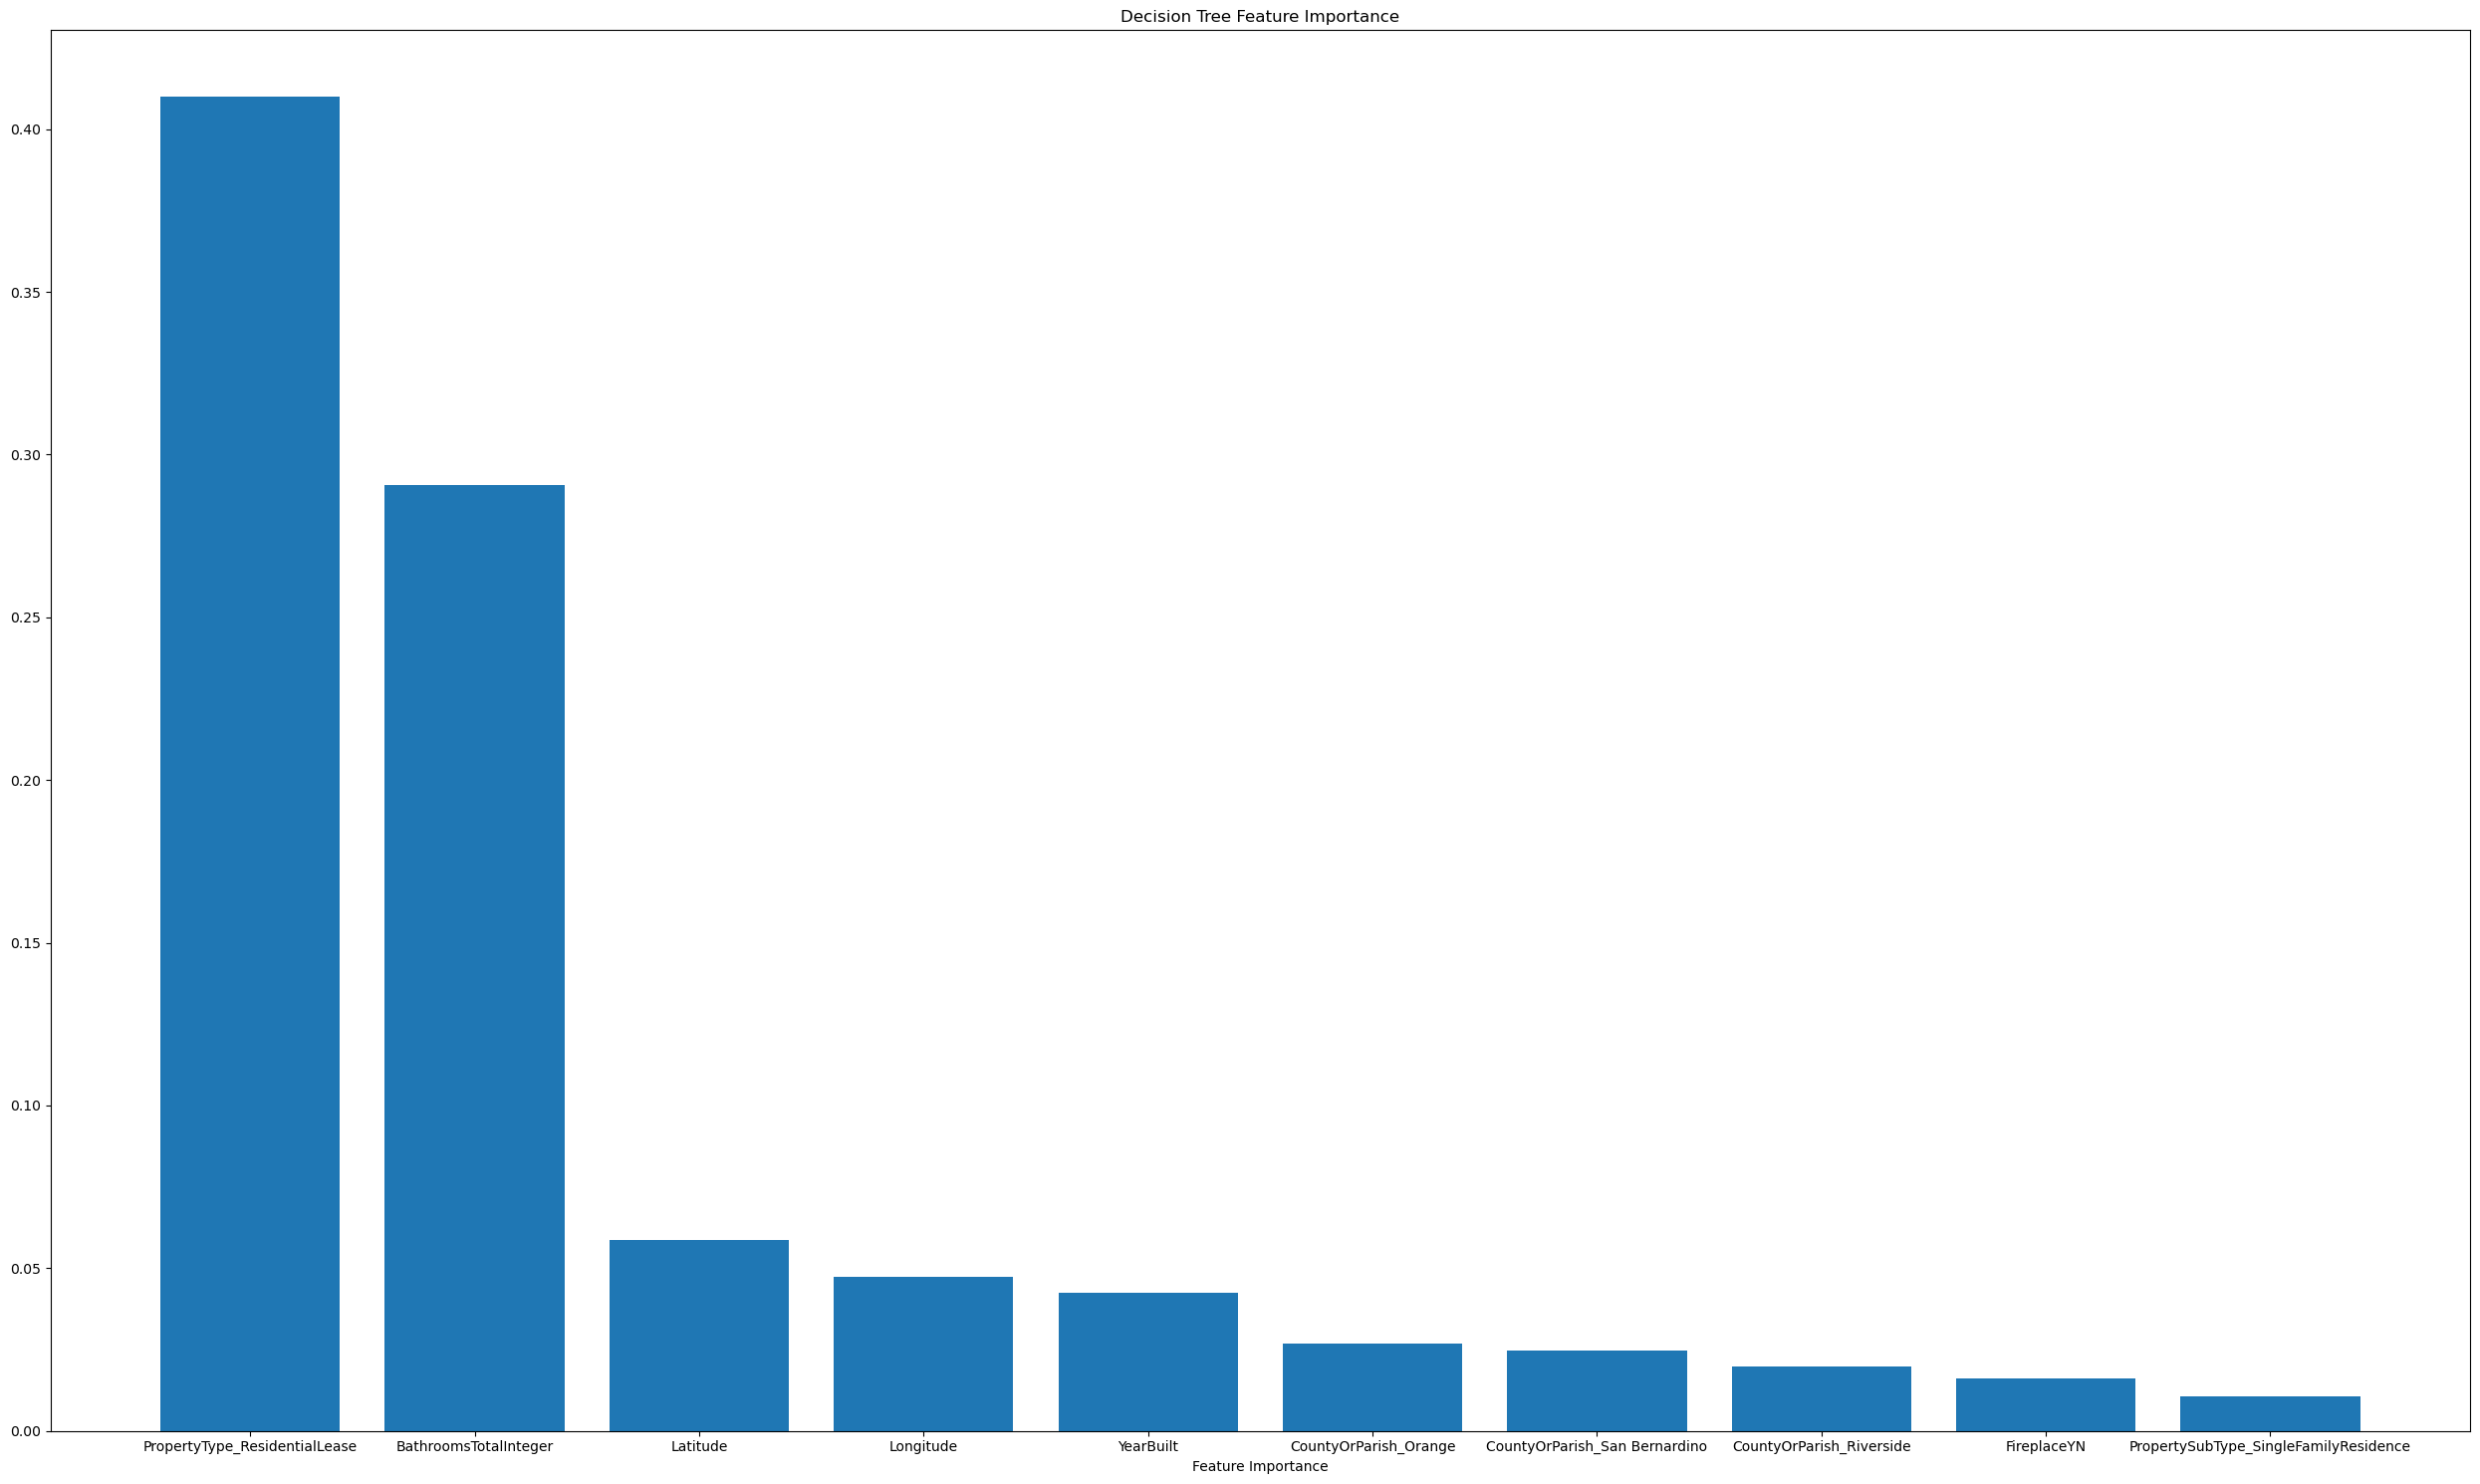

In [221]:
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

## 3.3 Random Forest Regressor

In [222]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

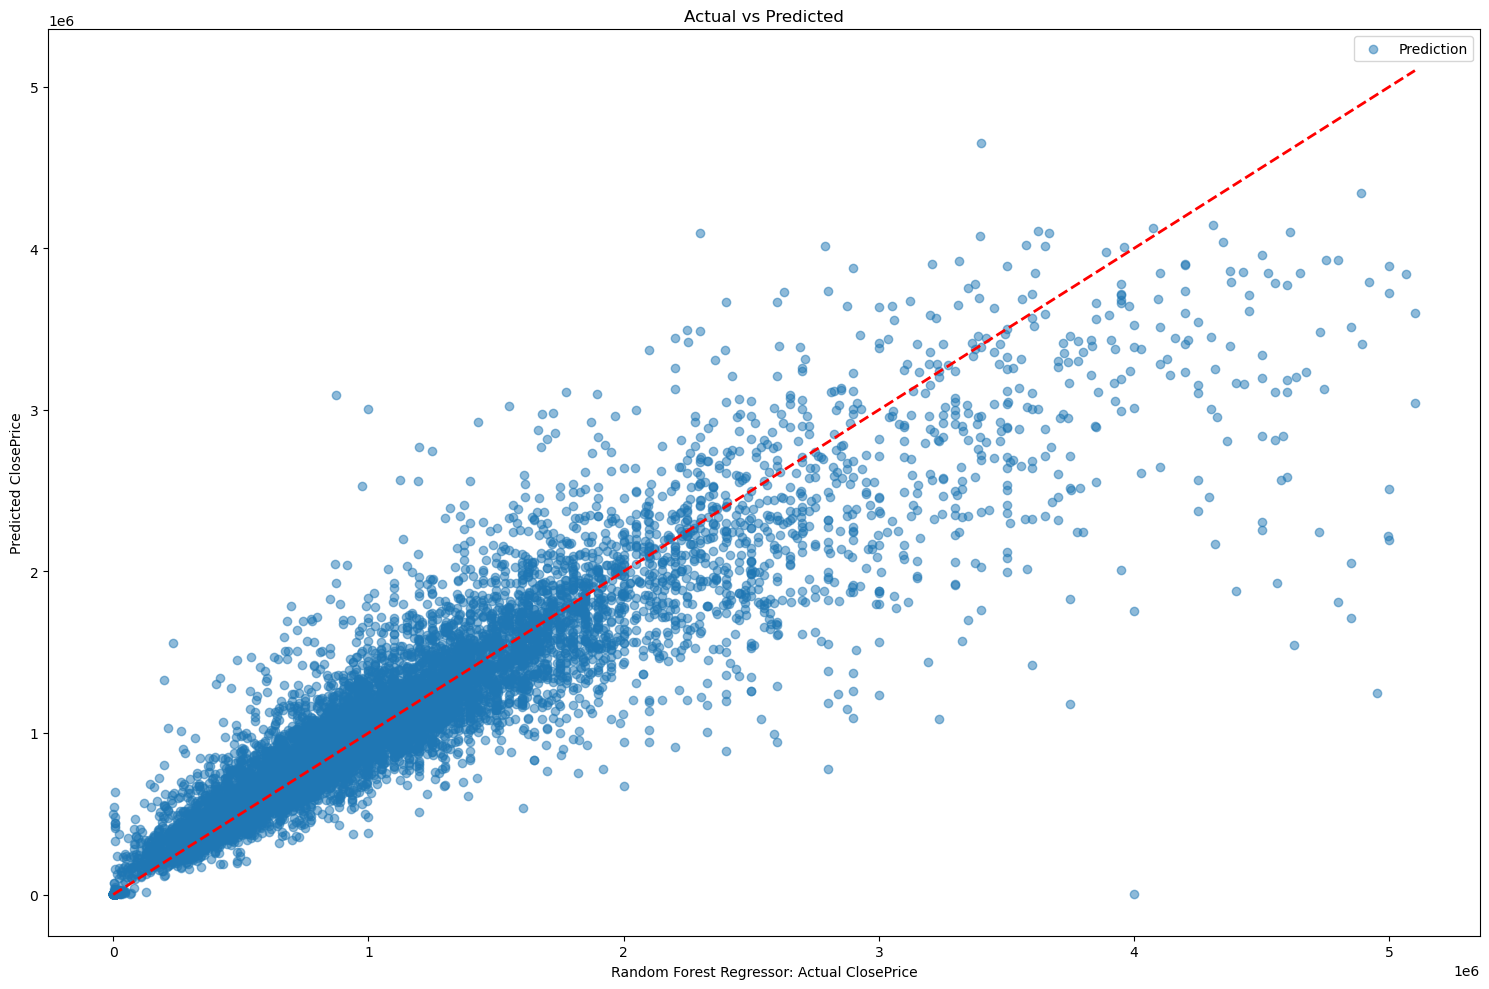

In [223]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Random Forest Regressor: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [224]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

results.append({
    "model":"Random Forest Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 9.65%
MAPE : 0.2620
R²   : 0.8856
MAE  : 123941.2141
MSE  : 63876528528.7177
RMSE : 252738.0631


In [225]:
print(model.score(X_train, y_train))

0.9841862266457732


### Feature importance

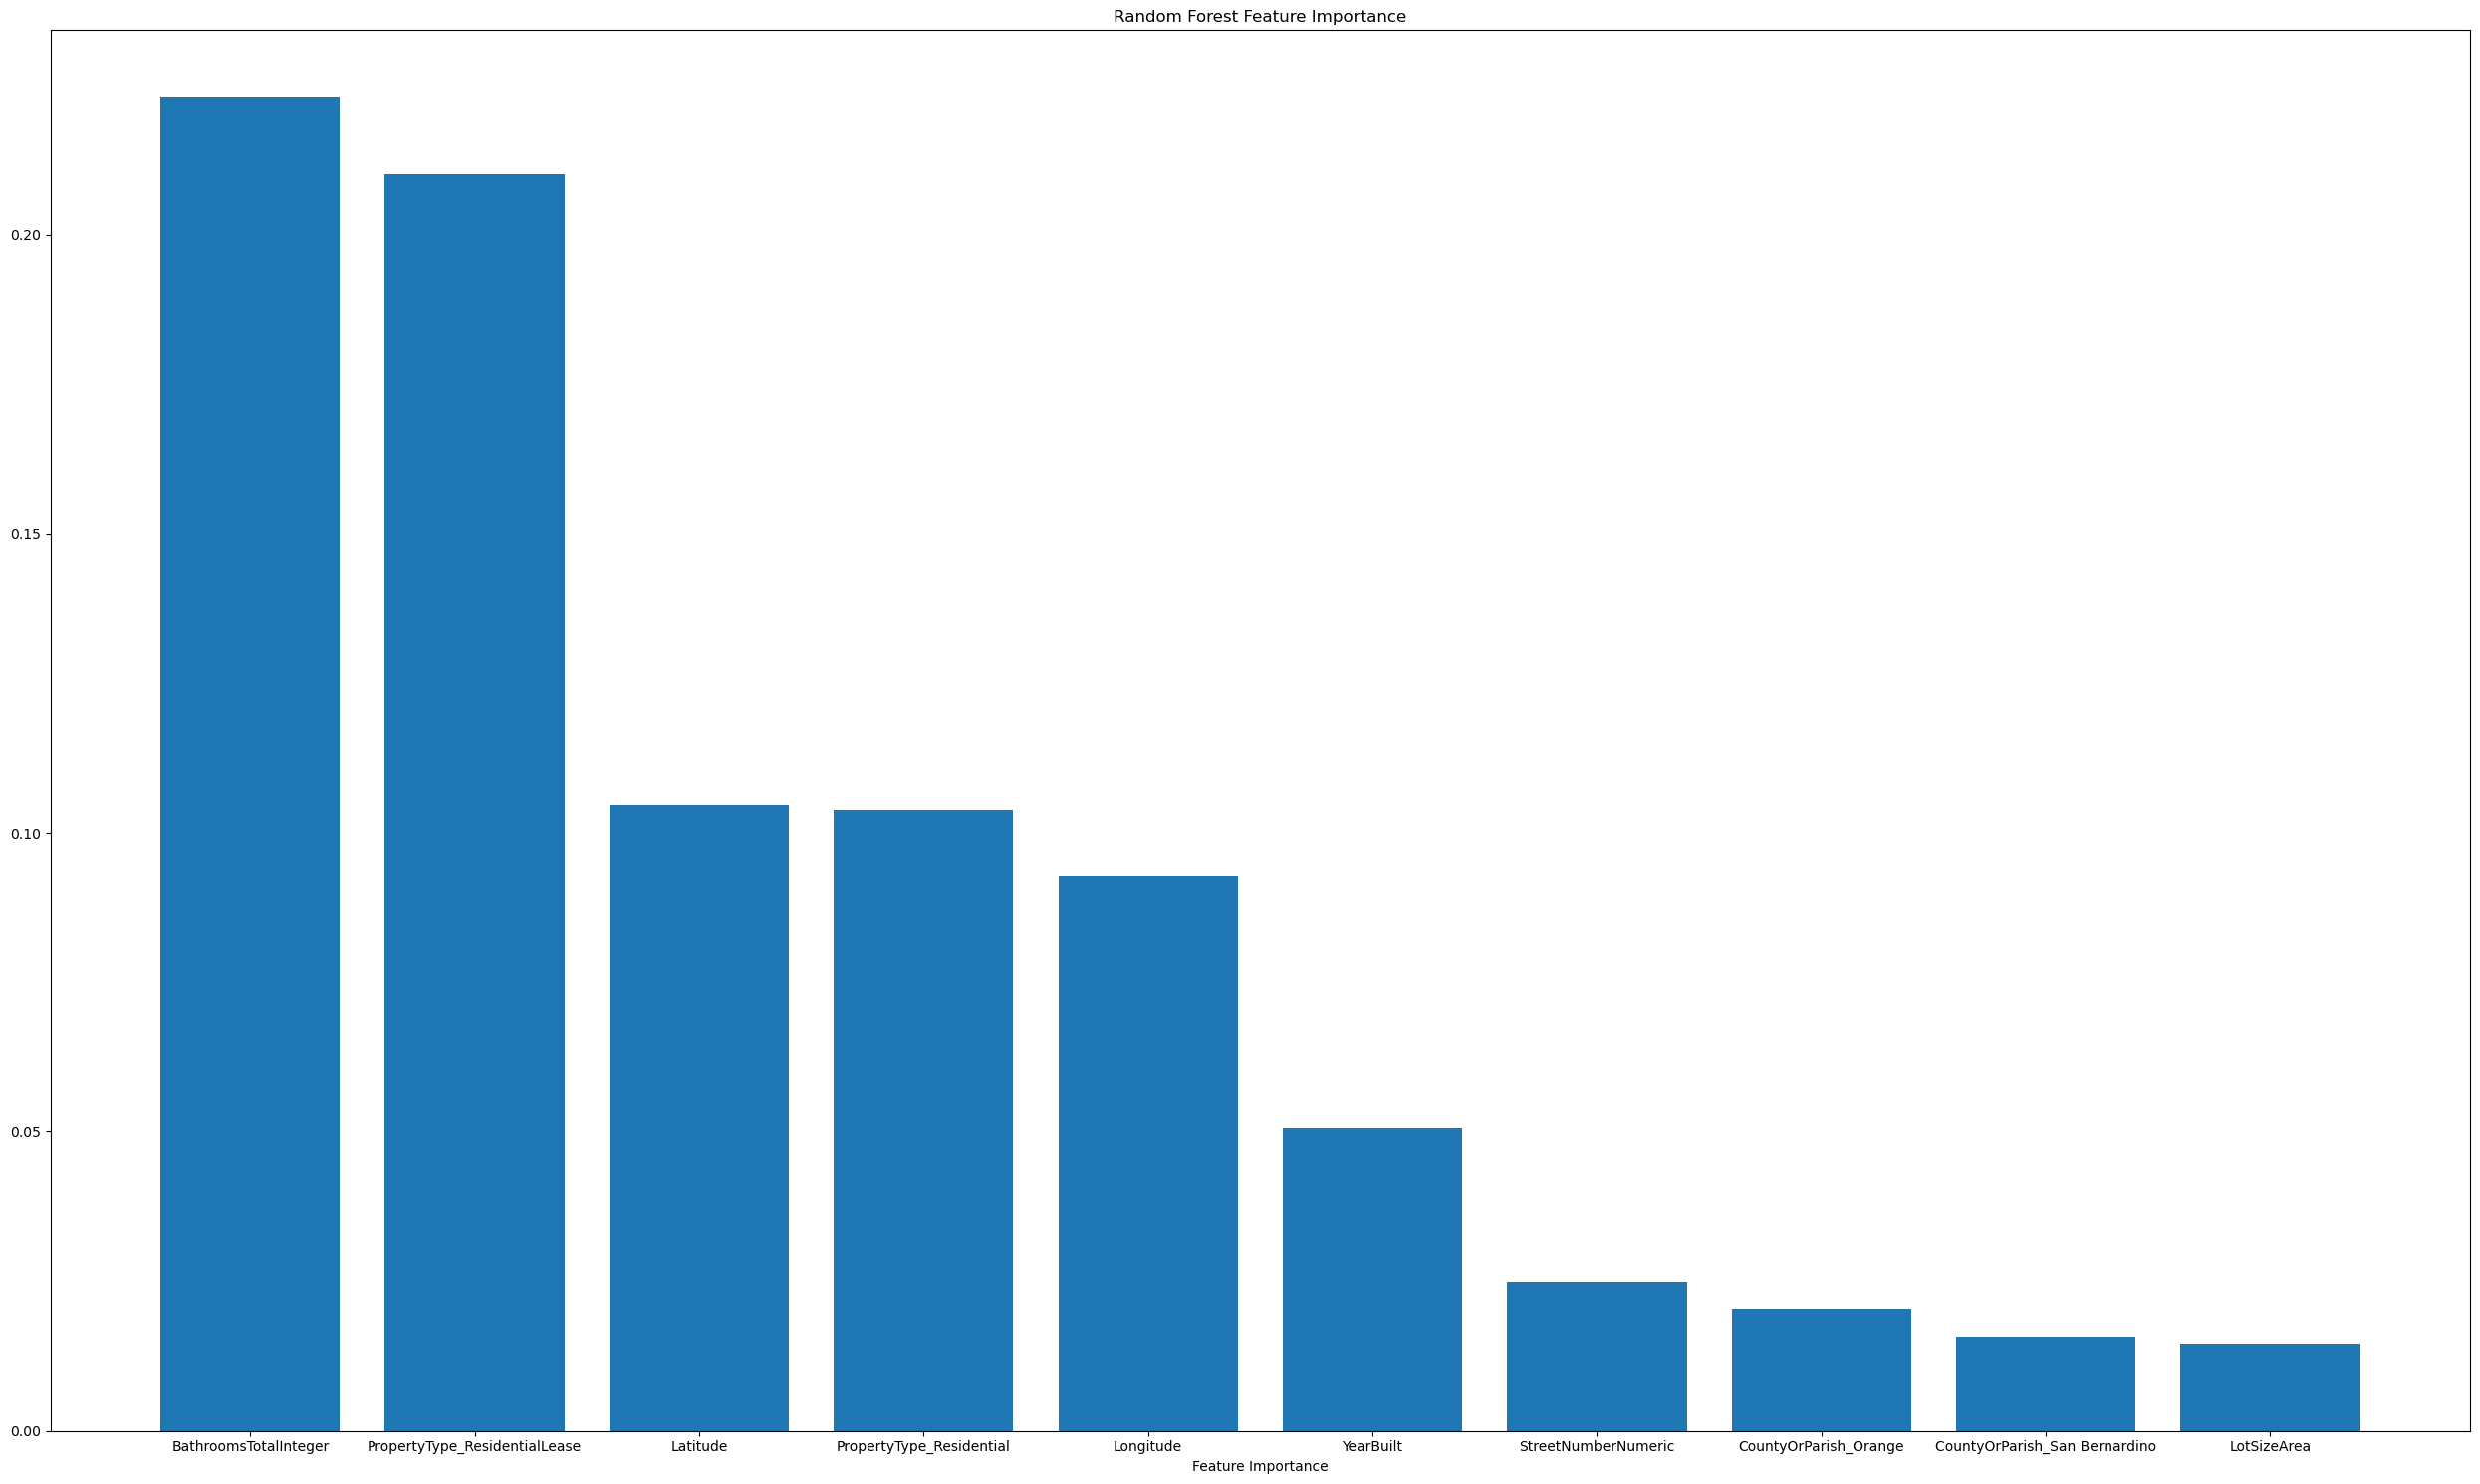

In [226]:
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# 4. Rolling-Origin Backtesting


In [227]:
result_roll=[]

for X in range(4,12):
    months = sorted(data_clean["date_ym"].unique())
    data_train=data_clean[data_clean['date_ym'].isin(months[:X])]
    data_test=data_clean[data_clean['date_ym']==months[X]]
    cols=["CountyOrParish","City","StateOrProvince"]
    for col in cols:
       top10 = data_train[col].value_counts().nlargest(10).index
       data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
       data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
    data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
    data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
    # keep the cols consistently
    data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
    X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_train["ClosePrice"]
    X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object"]).columns.tolist()), data_test["ClosePrice"]

    
    model = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------ElasticNet regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"ElasticNet Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })
    
    model = DecisionTreeRegressor(max_depth=10,random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------DecisionTree regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Decision Tree Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Random Forest regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll.append({
    "model":"Random Forest Regressor",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    

C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

--------------ElasticNet regression-------------
MdAPE: 40.15%
MAPE : 16.6553
R²   : 0.5513
MAE  : 315356.4024
MSE  : 233557485872.5001
RMSE : 483277.8558
--------------DecisionTree regression-------------
MdAPE: 19.79%
MAPE : 0.4639
R²   : 0.7205
MAE  : 208583.0736
MSE  : 145482339313.4751
RMSE : 381421.4720
--------------Random Forest regression-------------
MdAPE: 10.42%
MAPE : 0.3858
R²   : 0.8716
MAE  : 125018.3219
MSE  : 66845295060.9987
RMSE : 258544.5707


C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

--------------ElasticNet regression-------------
MdAPE: 38.68%
MAPE : 20.1509
R²   : 0.5561
MAE  : 314931.4068
MSE  : 234400316676.1357
RMSE : 484149.0645
--------------DecisionTree regression-------------
MdAPE: 19.61%
MAPE : 1.1519
R²   : 0.7091
MAE  : 213134.8471
MSE  : 153631674786.9533
RMSE : 391958.7667
--------------Random Forest regression-------------
MdAPE: 10.06%
MAPE : 0.7436
R²   : 0.8817
MAE  : 123824.5999
MSE  : 62462546037.3595
RMSE : 249925.0808


C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

...

--------------ElasticNet regression-------------
MdAPE: 42.33%
MAPE : 19.0094
R²   : 0.5681
MAE  : 313827.5175
MSE  : 232306591412.4230
RMSE : 481981.9410
--------------DecisionTree regression-------------
MdAPE: 20.14%
MAPE : 0.4578
R²   : 0.7425
MAE  : 199282.4652
MSE  : 138507849015.0775
RMSE : 372166.4265
--------------Random Forest regression-------------
MdAPE: 9.49%
MAPE : 0.3794
R²   : 0.8939
MAE  : 112462.2947
MSE  : 57048176205.5339
RMSE : 238847.6004


C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

--------------ElasticNet regression-------------
MdAPE: 40.62%
MAPE : 16.9635
R²   : 0.5567
MAE  : 321059.4297
MSE  : 240696041172.5963
RMSE : 490607.8283
--------------DecisionTree regression-------------
MdAPE: 19.73%
MAPE : 0.5923
R²   : 0.7216
MAE  : 209950.7504
MSE  : 151190361247.7459
RMSE : 388832.0476
--------------Random Forest regression-------------
MdAPE: 9.34%
MAPE : 0.3641
R²   : 0.8911
MAE  : 116564.2115
MSE  : 59139284587.2056
RMSE : 243185.6998


C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
C:\Users\23035\AppData\Local\Temp\ipykernel_58812\1958108943.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy 

--------------ElasticNet regression-------------
MdAPE: 39.36%
MAPE : 17.6352
R²   : 0.5376
MAE  : 328339.1113
MSE  : 263532788064.5851
RMSE : 513354.4468
--------------DecisionTree regression-------------
MdAPE: 19.41%
MAPE : 0.4759
R²   : 0.7275
MAE  : 213776.3708
MSE  : 155326919272.6307
RMSE : 394115.3629
--------------Random Forest regression-------------
MdAPE: 9.27%
MAPE : 0.3008
R²   : 0.8944
MAE  : 117196.8919
MSE  : 60212599078.8032
RMSE : 245382.5566


# 5. Record the result

In [228]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.to_csv("prediction_result_4.csv", index=True)
pd.DataFrame(results).to_csv("model_result_4.csv",index=True)
pd.DataFrame(result_roll).to_csv("model_result_roll_4.csv",index=True)

# 6. Report the result of comparsion between models

## Model Comparison

### ElasticNet Regression (Baseline)

The ElasticNet Regression model was used as the baseline model and achieved a test **R² of -2.77**. The result indicates that a linear model is not suitable for this housing price prediction task. Although ElasticNet combines both L1 and L2 regularization, it still assumes a linear relationship between features and house prices, which limits its performance on this dataset.

**Strengths**
- Simple and relatively easy to interpret.
- Helps reduce overfitting through regularization.
- Can perform feature selection by shrinking less important coefficients.

**Weaknesses**
- Assumes a linear relationship between features and house prices.
- Cannot capture complex nonlinear patterns.
- Lowest prediction accuracy among all tested models.

---

### Decision Tree Regressor

The Decision Tree Regressor achieved a test **R² of 0.72**, which is a significant improvement over the baseline model. The model can automatically learn nonlinear relationships between housing features and sale prices, resulting in much better prediction performance.

**Strengths**
- Captures nonlinear relationships automatically.
- Easy to understand and visualize.
- Significantly improves prediction accuracy compared with the baseline model.

**Weaknesses**
- Can overfit if the tree becomes too deep.
- Performance depends on hyperparameter settings.

---

### Random Forest Regressor

The Random Forest Regressor achieved the best performance with a test **R² of 0.89**. It also produced the lowest MAE, RMSE, and MdAPE among all tested models. By combining multiple decision trees, Random Forest reduces overfitting and provides more stable predictions.

**Strengths**
- Highest prediction accuracy.
- Handles complex nonlinear relationships well.
- More robust and stable than a single decision tree.
- Less prone to overfitting by averaging multiple trees.

**Weaknesses**
- Longer training time.
- More difficult to interpret than a single decision tree.

---

### Overall Comparison

The test R² values are:

- **ElasticNet Regression:** **-2.77**
- **Decision Tree:** **0.72**
- **Random Forest:** **0.89**

Using only the most recent **six months** of housing transaction data for training, the tree-based models clearly outperformed the ElasticNet baseline. The Decision Tree captured nonlinear relationships much better than the linear model, while the Random Forest further improved prediction accuracy by combining multiple decision trees. Among all tested models, **Random Forest achieved the best overall performance**, making it the most suitable model for this dataset.

# 7. Feature engineer

Example of sample features you can engineer: bed/bath ratio, age of property in years

In [300]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203277 entries, 0 to 203276
Data columns (total 37 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   ViewYN                           203277 non-null  int64  
 1   PoolPrivateYN                    203277 non-null  int64  
 2   ClosePrice                       203277 non-null  float64
 3   Latitude                         203277 non-null  float64
 4   Longitude                        203277 non-null  float64
 5   LivingArea                       203277 non-null  float64
 6   MLSAreaMajor                     203277 non-null  object 
 7   CountyOrParish                   203277 non-null  object 
 8   ParkingTotal                     203277 non-null  float64
 9   PropertySubType                  203277 non-null  object 
 10  LotSizeAcres                     203277 non-null  float64
 11  YearBuilt                        203277 non-null  float64
 12  St

In [301]:
data_clean_2=data_clean.copy()
data_clean_2["BedBathRatio"]=data_clean_2["BedBathRatio"] = np.where(data_clean["BathroomsTotalInteger"] == 0,0, data_clean["BedroomsTotal"] / data_clean["BathroomsTotalInteger"])
data_clean_2["Years"]=2026-data_clean["YearBuilt"]

In [302]:
data_clean_2.head()

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,NewConstructionYN_missing,PropertyType_CommercialLease,PropertyType_CommercialSale,PropertyType_Land,PropertyType_ManufacturedInPark,PropertyType_Residential,PropertyType_ResidentialIncome,PropertyType_ResidentialLease,BedBathRatio,Years
0,1,0,6500.0,33.475311,-117.708995,3870.0,MB - Monarch Beach,Orange,2.0,SingleFamilyResidence,...,0,False,False,False,False,False,False,True,1.000000,54.0
1,1,0,1800000.0,33.899427,-117.977995,7740.0,83 - Fullerton,Orange,3.0,SingleFamilyResidence,...,0,False,False,False,False,True,False,False,1.250000,23.0
2,1,0,1200000.0,34.095980,-118.221993,4697.0,680 - Mount Washington,Los Angeles,2.0,SingleFamilyResidence,...,0,False,False,False,False,True,False,False,1.000000,86.0
3,1,1,3200.0,33.773119,-116.343788,1581.0,324 - East Palm Desert,Riverside,2.0,Condominium,...,0,False,False,False,False,False,False,True,1.333333,12.0
4,1,0,1425000.0,33.884526,-117.778002,7500.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,0,False,False,False,False,True,False,False,1.500000,38.0


# 8. Adding more detailed geographic layer using school districts

## 8.1 load the geographic

In [303]:
import geopandas as gpd
districts=gpd.read_file('DistrictAreas2526_-284845464123469011.geojson')
districts_filter=districts[districts["DistrictType"]=="Unified"]
districts_filter

,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictName,DistrictType,GradeLow,GradeHigh,...,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc,geometry
0,1,2025-26,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,...,0,0.0,1302,12.1,4259,39.5,11.248886,21,"21 - Suburban, Large","MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2025-26,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,...,0,0.0,363,9.7,1247,33.3,1.789975,21,"21 - Suburban, Large","POLYGON ((-13612893.866 4565099.707, -13612896..."
2,3,2025-26,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,...,0,0.0,1118,11.9,2710,28.8,10.434281,12,"12 - City, Midsize","POLYGON ((-13609482.48 4565074.597, -13609483...."
3,4,2025-26,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,...,2,0.0,1186,12.2,3784,39.0,66.885261,21,"21 - Suburban, Large","MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,5,2025-26,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,...,0,0.0,98,16.1,407,66.7,1.273923,21,"21 - Suburban, Large","POLYGON ((-13613999.038 4555592.769, -13614126..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926,932,2025-26,0641580,5772694,57726940000000,Yolo,Washington Unified,Unified,PK,12,...,1,0.0,1242,15.1,3796,46.2,27.524200,13,"13 - City, Small","POLYGON ((-13538678.161 4660316.003, -13538674..."
927,933,2025-26,0642930,5772702,57727020000000,Yolo,Winters Joint Unified,Unified,PK,12,...,105,5.0,335,16.0,1185,56.7,126.903010,31,"31 - Town, Fringe","POLYGON ((-13578206.161 4668467.848, -13577796..."
928,934,2025-26,0643080,5772710,57727100000000,Yolo,Woodland Joint Unified,Unified,PK,12,...,296,3.2,1704,18.3,6827,73.4,309.459071,23,"23 - Suburban, Small","POLYGON ((-13580837.089 4696906.449, -13580814..."
930,936,2025-26,0624090,5872736,58727360000000,Yuba,Marysville Joint Unified,Unified,PK,12,...,47,0.4,1673,16.0,7648,73.2,462.497708,22,"22 - Suburban, Midsize","POLYGON ((-13540500.026 4756982.131, -13540491..."


In [304]:
districts_filter.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 345 entries, 0 to 934
Data columns (total 51 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   OBJECTID          345 non-null    int32   
 1   Year              345 non-null    object  
 2   FedID             345 non-null    object  
 3   CDCode            345 non-null    object  
 4   CDSCode           345 non-null    object  
 5   CountyName        345 non-null    object  
 6   DistrictName      345 non-null    object  
 7   DistrictType      345 non-null    object  
 8   GradeLow          345 non-null    object  
 9   GradeHigh         345 non-null    object  
 10  GradeLowCensus    345 non-null    object  
 11  GradeHighCensus   345 non-null    object  
 12  AssistStatus      345 non-null    object  
 13  UpdateNotes       133 non-null    object  
 14  EnrollTotal       345 non-null    int32   
 15  EnrollCharter     345 non-null    int32   
 16  EnrollNonCharter  

In [305]:
#points from the data
points=gpd.GeoDataFrame(data_clean_2,geometry=gpd.points_from_xy(data_clean_2["Longitude"],data_clean_2["Latitude"]), crs="EPSG:4326")

In [306]:
districts_filter = districts_filter.to_crs("EPSG:4326")

In [307]:
points=gpd.sjoin(points,districts_filter,how="left",predicate="within")#Left Join

In [308]:
points.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 203277 entries, 0 to 203276
Data columns (total 91 columns):
 #   Column                           Non-Null Count   Dtype   
---  ------                           --------------   -----   
 0   ViewYN                           203277 non-null  int64   
 1   PoolPrivateYN                    203277 non-null  int64   
 2   ClosePrice                       203277 non-null  float64 
 3   Latitude                         203277 non-null  float64 
 4   Longitude                        203277 non-null  float64 
 5   LivingArea                       203277 non-null  float64 
 6   MLSAreaMajor                     203277 non-null  object  
 7   CountyOrParish                   203277 non-null  object  
 8   ParkingTotal                     203277 non-null  float64 
 9   PropertySubType                  203277 non-null  object  
 10  LotSizeAcres                     203277 non-null  float64 
 11  YearBuilt                        203277 non-

# 9. Comparsion after feature engineer and add a geo feature

drop unrelated feature

In [309]:
points.drop(columns=["index_right","OBJECTID","FedID"])

,ViewYN,PoolPrivateYN,ClosePrice,Latitude,Longitude,LivingArea,MLSAreaMajor,CountyOrParish,ParkingTotal,PropertySubType,...,HOMpct,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc
0,1,0,6500.0,33.475311,-117.708995,3870.0,MB - Monarch Beach,Orange,2.0,SingleFamilyResidence,...,7.0,15.0,0.0,7174.0,15.5,16342.0,35.2,157.385389,21,"21 - Suburban, Large"
1,1,0,1800000.0,33.899427,-117.977995,7740.0,83 - Fullerton,Orange,3.0,SingleFamilyResidence,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0,1200000.0,34.095980,-118.221993,4697.0,680 - Mount Washington,Los Angeles,2.0,SingleFamilyResidence,...,2.4,1294.0,0.3,81461.0,16.4,410978.0,82.7,699.955103,11,"11 - City, Large"
3,1,1,3200.0,33.773119,-116.343788,1581.0,324 - East Palm Desert,Riverside,2.0,Condominium,...,10.8,13.0,0.1,2671.0,13.6,18133.0,92.4,496.440859,21,"21 - Suburban, Large"
4,1,0,1425000.0,33.884526,-117.778002,7500.0,85 - Yorba Linda,Orange,2.0,SingleFamilyResidence,...,13.9,15.0,0.1,3161.0,14.2,10492.0,47.1,39.259300,21,"21 - Suburban, Large"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203272,1,0,865000.0,34.242304,-116.802871,868586.4,BBC - Big Bear City,San Bernardino,2.0,SingleFamilyResidence,...,10.3,4.0,0.2,330.0,15.3,1495.0,69.2,236.300524,32,"32 - Town, Distant"
203273,1,1,4000.0,33.701018,-116.292460,7405.0,313 - La Quinta South of HWY 111,Riverside,3.0,SingleFamilyResidence,...,2.3,131.0,0.5,3446.0,13.6,19324.0,76.5,768.026072,21,"21 - Suburban, Large"
203274,0,0,127500.0,34.251991,-116.820227,1440.0,BBC - Big Bear City,San Bernardino,2.0,Unknown,...,10.3,4.0,0.2,330.0,15.3,1495.0,69.2,236.300524,32,"32 - Town, Distant"
203275,0,0,595000.0,37.824500,-122.281570,4389.0,Unknown,Alameda,3.0,SingleFamilyResidence,...,4.6,27.0,0.1,7646.0,17.6,34974.0,80.4,53.162702,11,"11 - City, Large"


handle missing value

In [310]:
points=points.dropna()

### 9.1 Test train split

In [311]:
X=7 # past 2 month
months = sorted(points["date_ym"].unique())
# data_train=data_clean[data_clean['date_ym'].isin(months[-X:-2])]
# data_valid=data_clean[data_clean['date_ym'].isin(months[-2:-1])]
# data_test=data_clean[data_clean['date_ym']==months[-1]]
data_train=points[points['date_ym'].isin(months[-X:-1])]
data_test=points[points['date_ym']==months[-1]]
print(data_train['date_ym'].value_counts())
print(data_test['date_ym'].value_counts())
data_train.info()

2026-04-01    5793
2026-05-01    5751
2026-03-01    5676
2025-12-01    5101
2026-02-01    4493
2026-01-01    4118
Name: date_ym, dtype: int64
2026-06-01    5998
Name: date_ym, dtype: int64
<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 30932 entries, 104840 to 186866
Data columns (total 91 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   ViewYN                           30932 non-null  int64   
 1   PoolPrivateYN                    30932 non-null  int64   
 2   ClosePrice                       30932 non-null  float64 
 3   Latitude                         30932 non-null  float64 
 4   Longitude                        30932 non-null  float64 
 5   LivingArea                       30932 non-null  float64 
 6   MLSAreaMajor                     30932 non-null  object  
 7   CountyOrParish                   30932 non-null  object  
 8   ParkingTotal                     30932 non-null  floa

delete unrealted features

In [312]:
data_train["CountyName"].value_counts()

Los Angeles        10591
Riverside           6017
Orange              5239
San Bernardino      4793
Alameda             1770
San Luis Obispo      734
Butte                677
Santa Clara          140
Fresno               127
Kern                 106
Madera                98
Solano                98
Mendocino             89
Mariposa              63
Ventura               62
Santa Barbara         60
Lake                  50
Stanislaus            41
San Joaquin           36
Sacramento            26
Napa                  24
Tulare                19
Santa Cruz            15
Merced                13
Plumas                 7
Calaveras              7
Marin                  7
Sutter                 6
Sonoma                 4
Lassen                 3
San Benito             2
Colusa                 2
Mono                   2
Monterey               1
El Dorado              1
Imperial               1
Inyo                   1
Name: CountyName, dtype: int64

In [313]:
data_train["LocaleDesc"].value_counts()

11 - City, Large          12720
21 - Suburban, Large       9102
12 - City, Midsize         3939
22 - Suburban, Midsize     1266
13 - City, Small           1003
42 - Rural, Distant         794
41 - Rural, Fringe          579
31 - Town, Fringe           567
32 - Town, Distant          519
33 - Town, Remote           161
43 - Rural, Remote          157
23 - Suburban, Small        125
Name: LocaleDesc, dtype: int64

convert data type

In [314]:
cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode","DistrictName","GradeLow","GradeHigh","GradeLowCensus","GradeHighCensus","AssistStatus","LocaleCode","LocaleDesc"]
for col in cols:
    top10 = data_train[col].value_counts().nlargest(10).index
    data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
    data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
# 保证列一致
data_test = data_test.reindex(columns=data_train.columns, fill_value=0)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [315]:
# remove some columns that related to the feature
X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]

In [316]:
result_after=[]

## 9.2 ElasticNet - Baseline model

In [318]:
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:648: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.628e+15, tolerance: 1.675e+12
  model = cd_fast.enet_coordinate_descent(


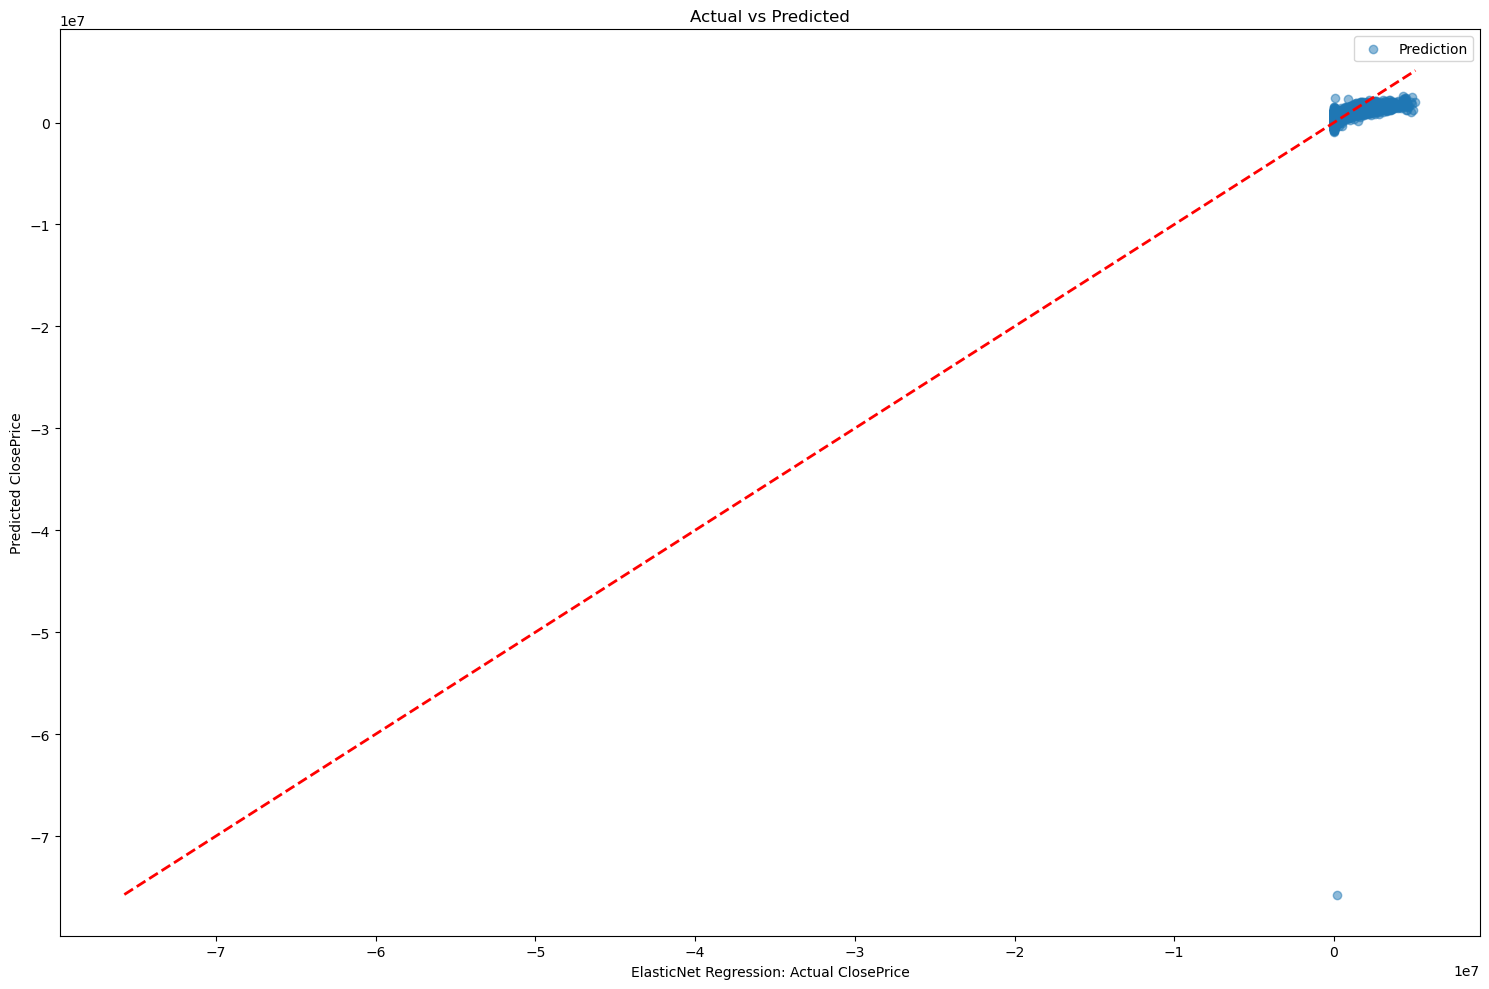

In [319]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("ElasticNet Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [320]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

result_after.append({
    "model":"Ridge Regression- Baseline model",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})


MdAPE: 36.52%
MAPE : 19.8116
R²   : -1.1274
MAE  : 306334.9554
MSE  : 1173522079354.0120
RMSE : 1083292.2410


## 9.3 Decision Tree Regressor

In [322]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

model = DecisionTreeRegressor(max_depth=10,random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

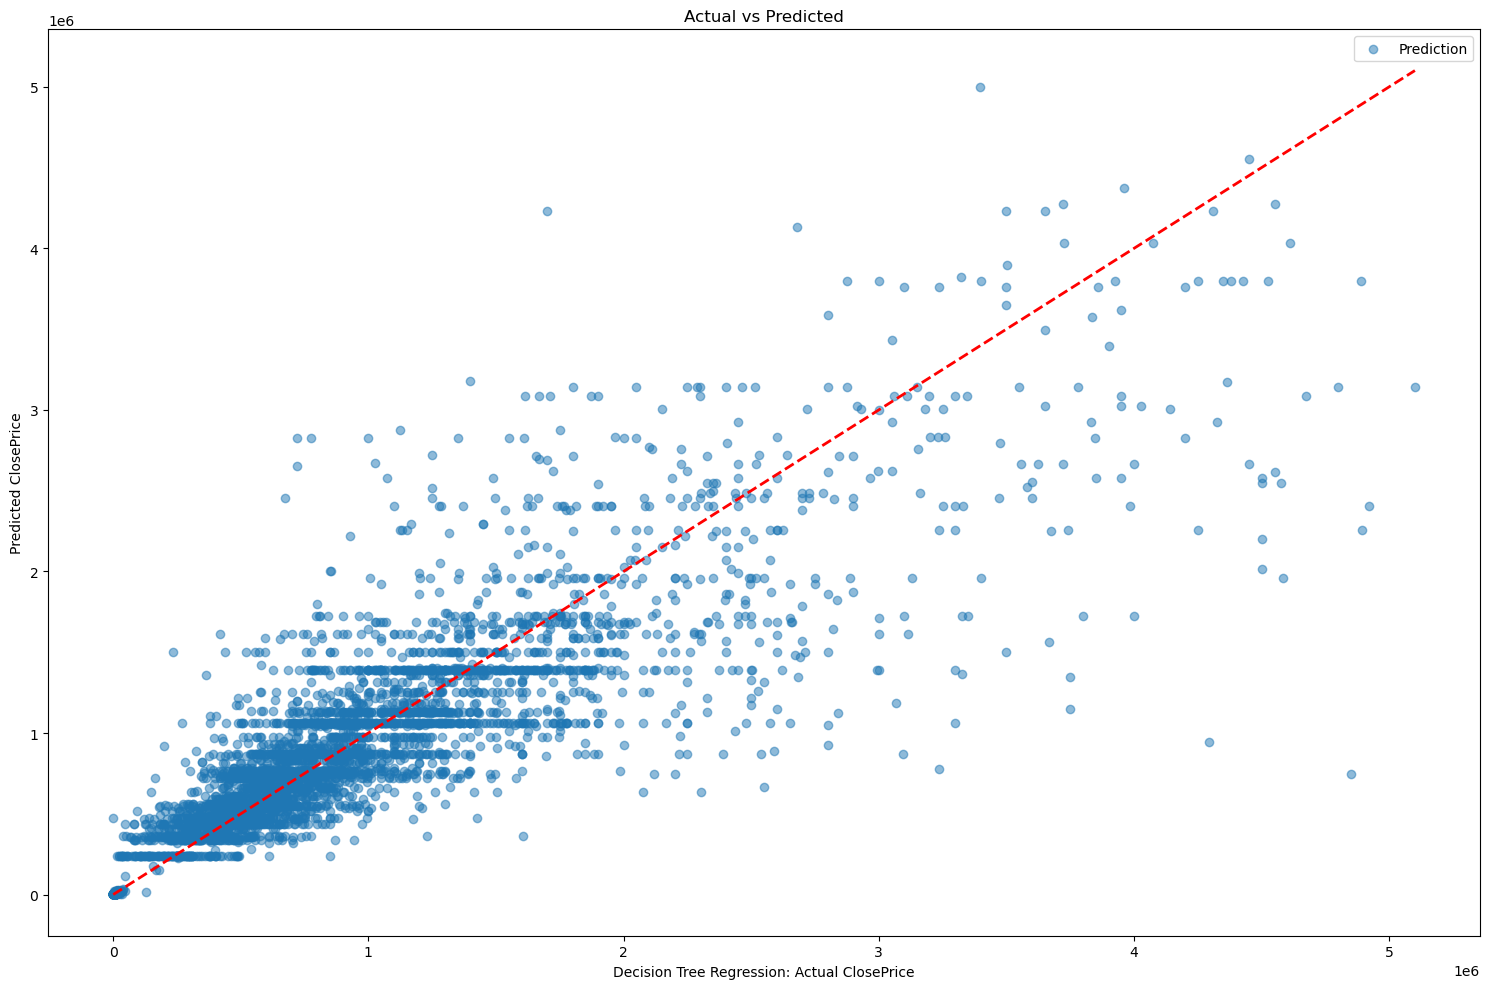

In [323]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Decision Tree Regression: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [324]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

result_after.append({
    "model":"Decision Tree Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 16.85%
MAPE : 0.4071
R²   : 0.7923
MAE  : 174270.6202
MSE  : 114556669861.5257
RMSE : 338462.2133


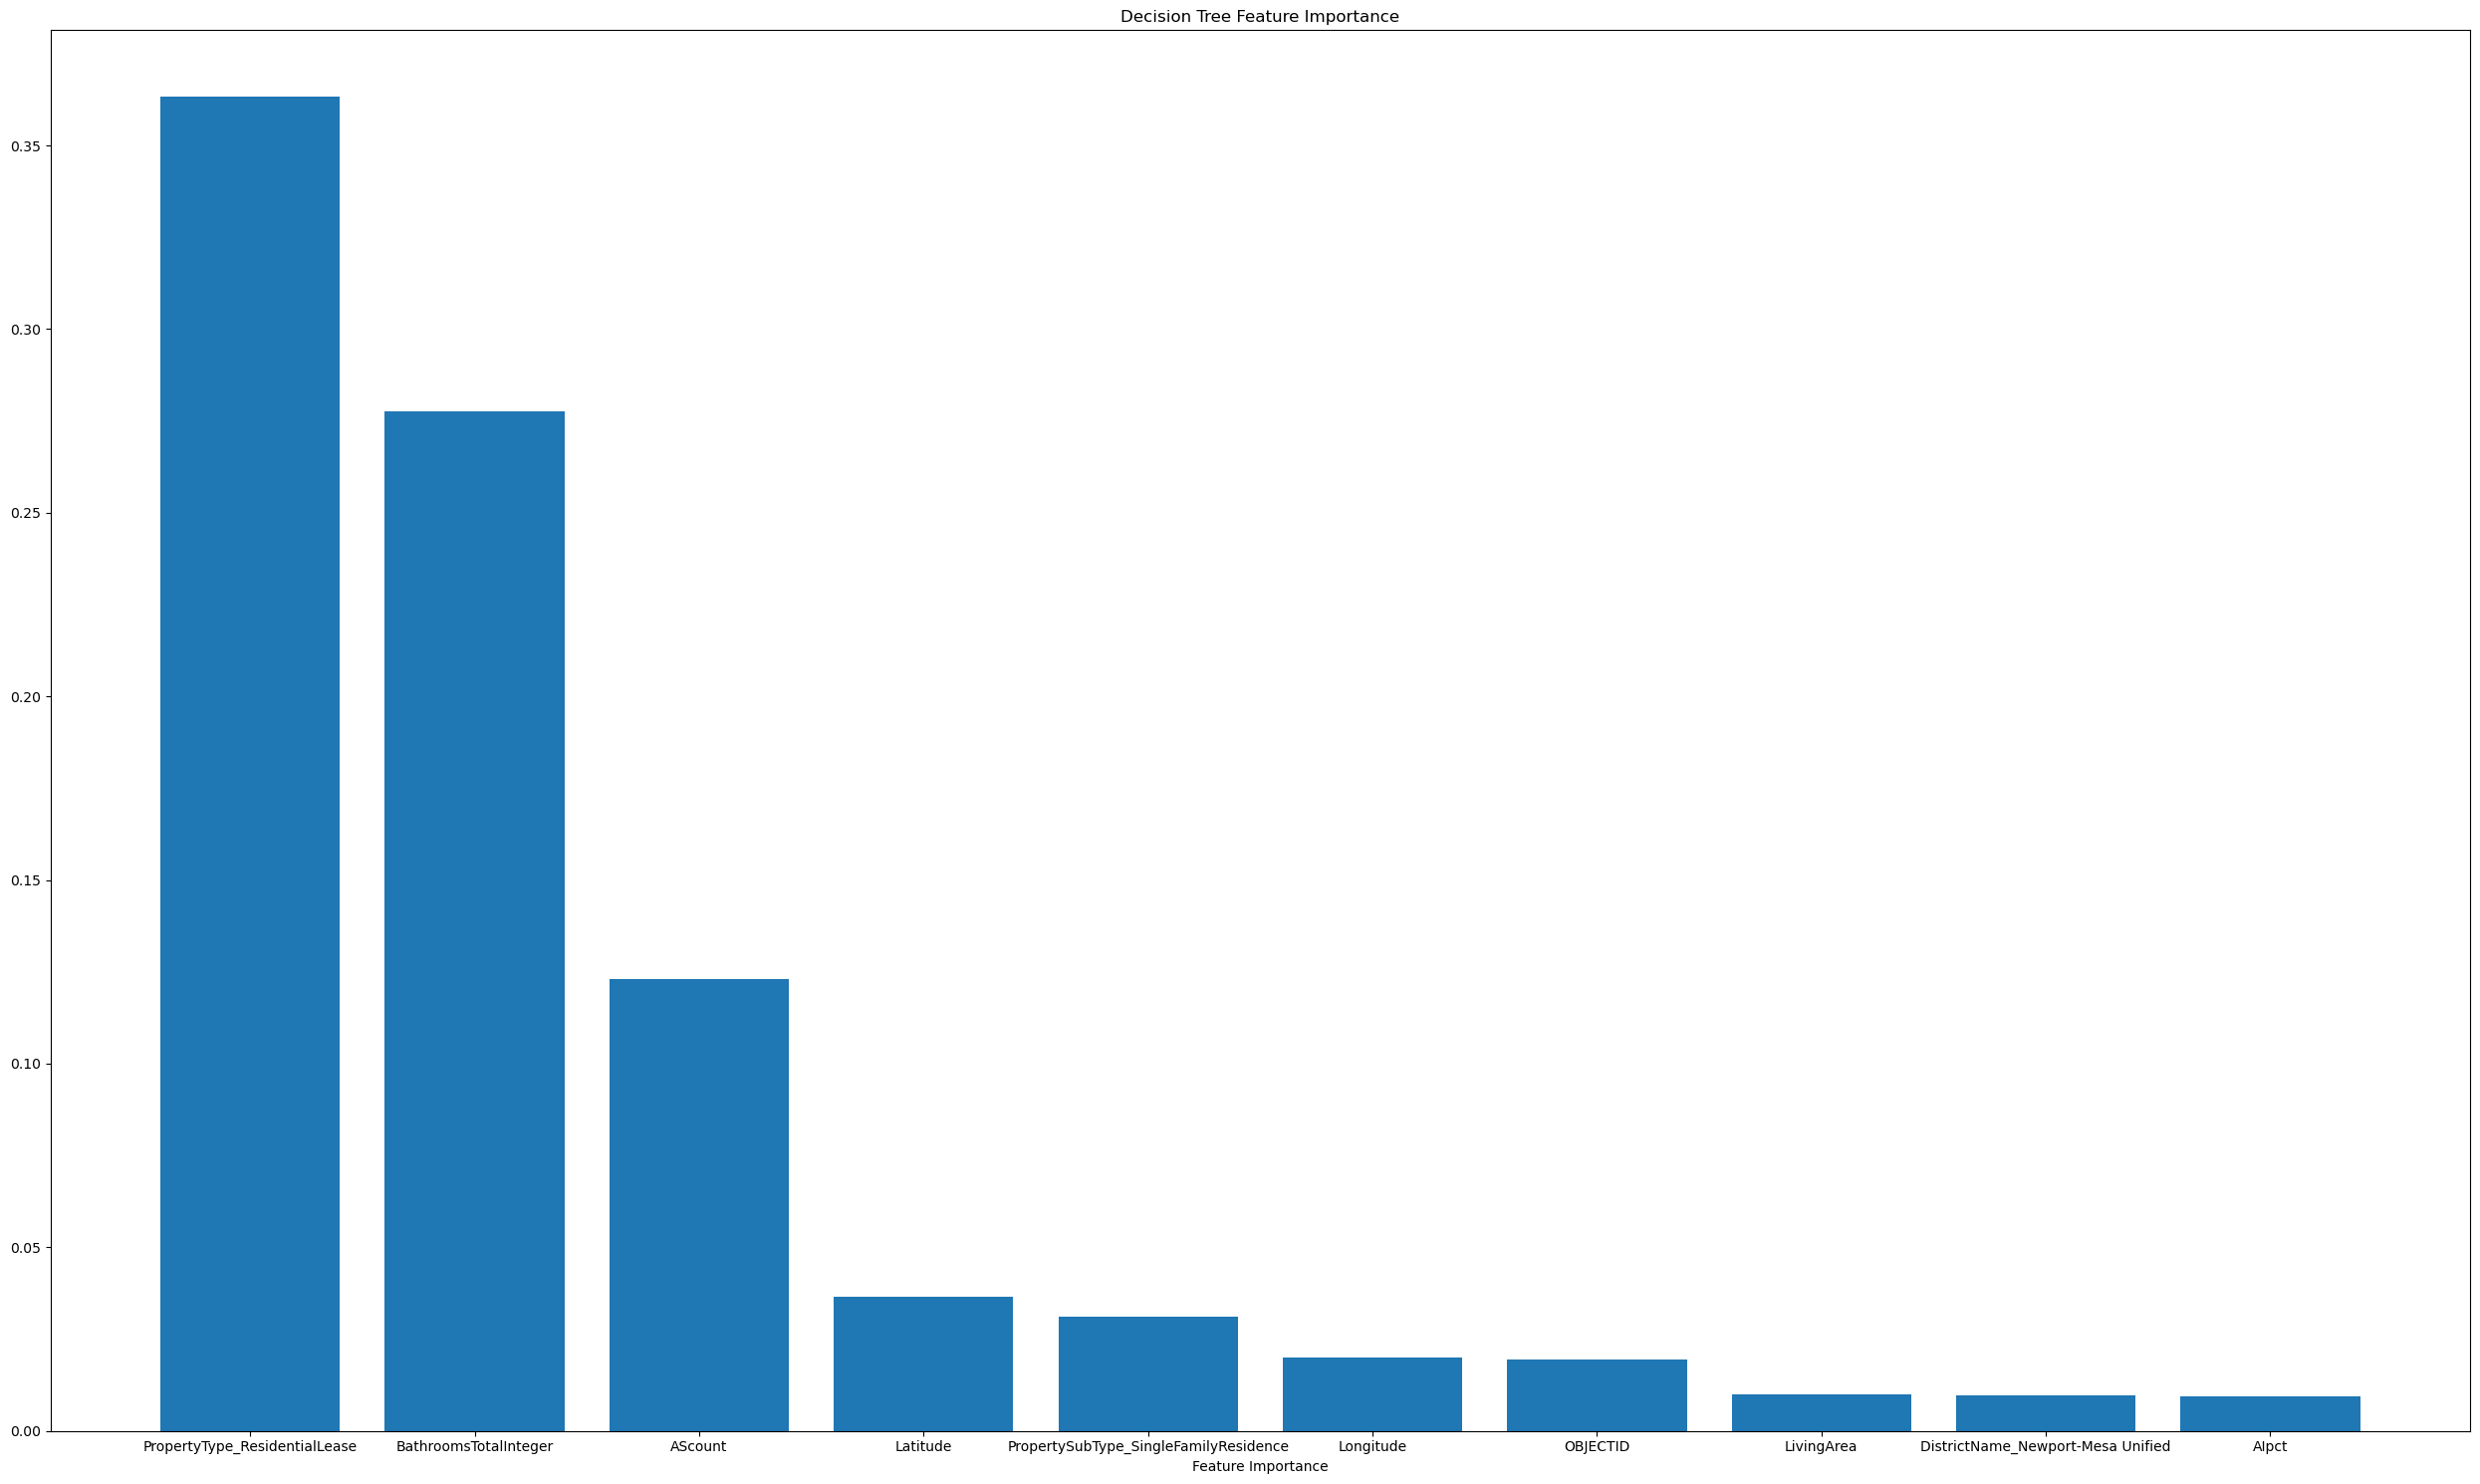

In [325]:
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

## 9.4 Random Forest Regressor

In [326]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

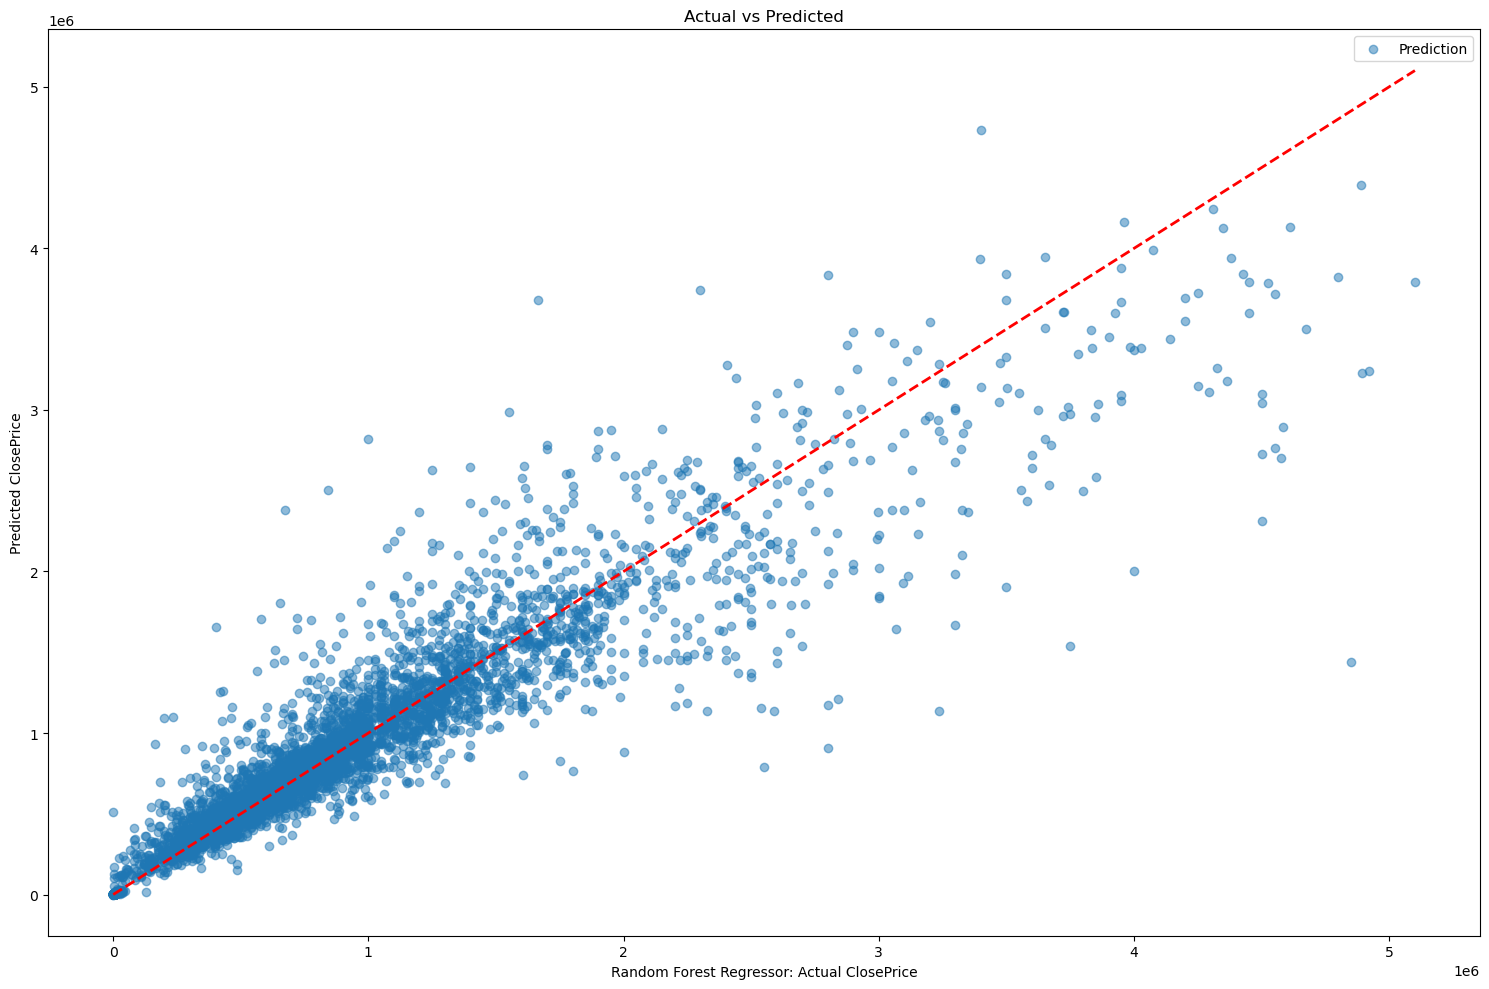

In [327]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label="Prediction")

# 理想预测线 y=x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Random Forest Regressor: Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.legend()
plt.show()

In [328]:
# Median Absolute Percentage Error, MAPE,R2,MAE,MSE,RMSE

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100

print(f"MdAPE: {mdape:.2f}%")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")

result_after.append({
    "model":"Decision Tree Regressor",
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
})

MdAPE: 10.18%
MAPE : 0.3484
R²   : 0.8906
MAE  : 118806.6562
MSE  : 60366412375.9131
RMSE : 245695.7720


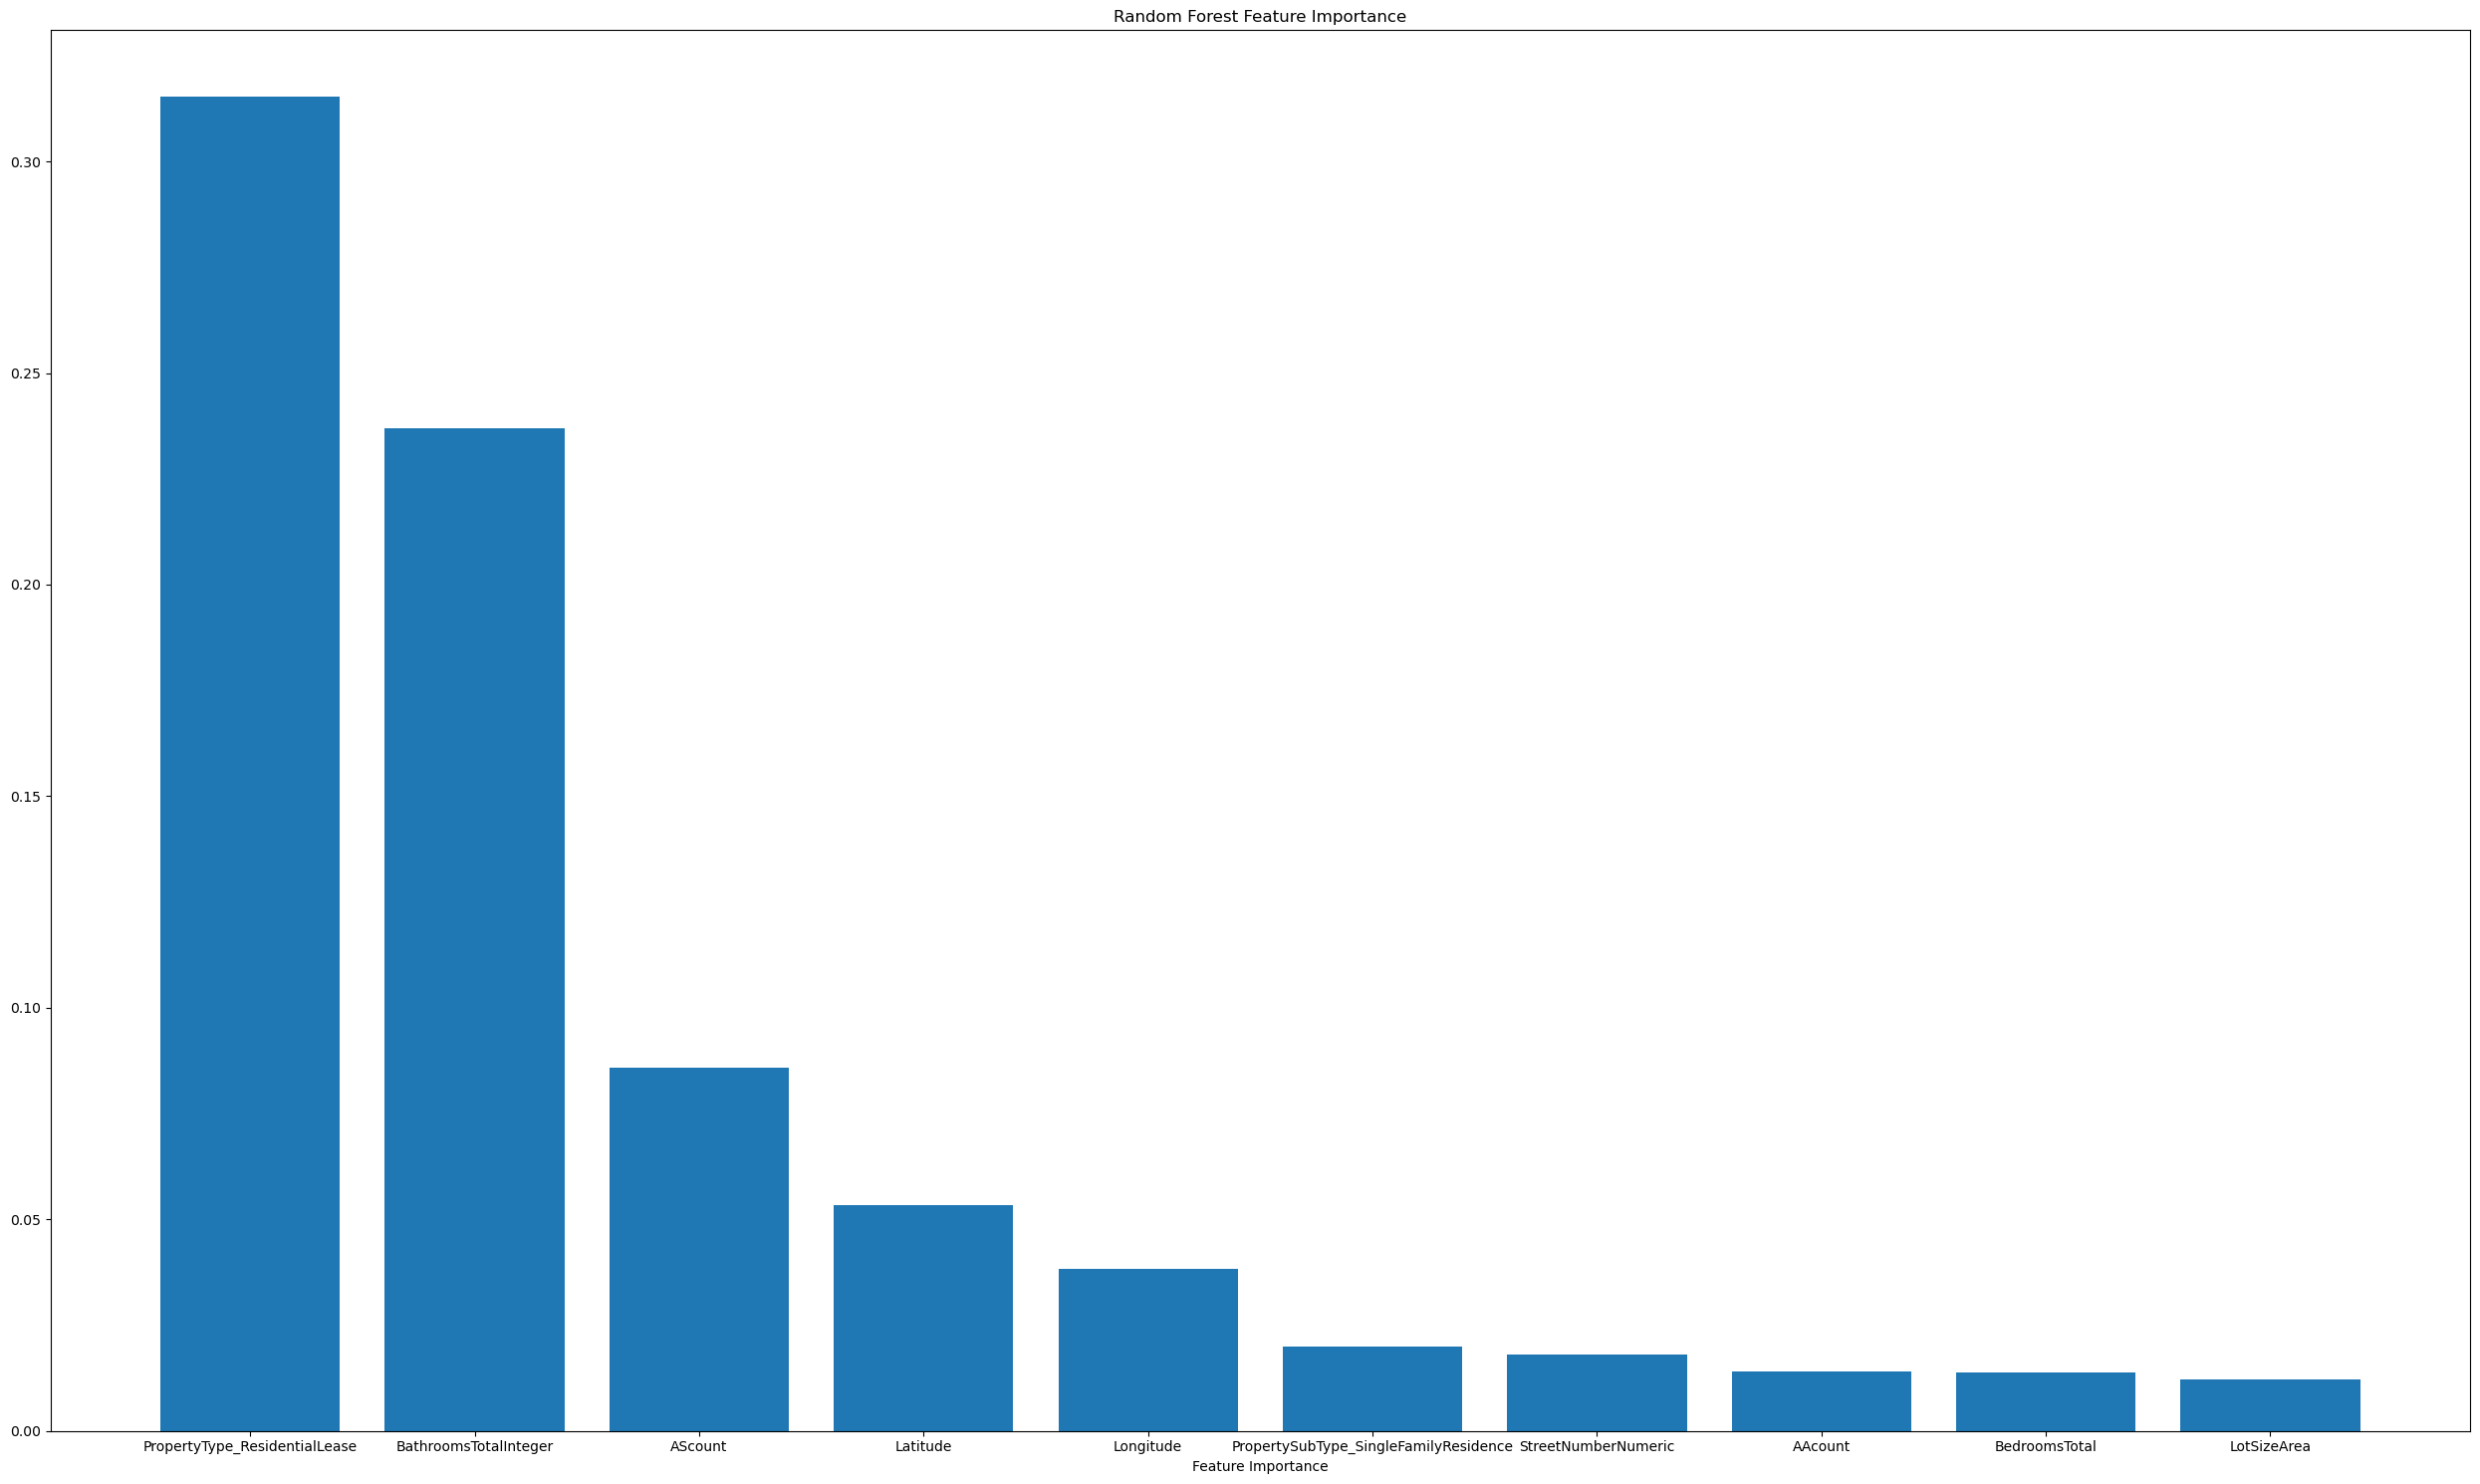

In [329]:
# Feature importance
import matplotlib.pyplot as plt


plt.figure(figsize=(25,15))
data=[[x,y] for x,y in zip(X_train.columns, model.feature_importances_)]
data=sorted(data,key=lambda x:x[1], reverse=True)
features = [x[0] for x in data]
importance = [x[1] for x in data]
plt.bar(features[:10],importance[:10])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## 9.5 Rolling-Origin Backtesting

In [331]:
result_roll_after=[]

for X in range(4,12):
    months = sorted(points["date_ym"].unique())
    data_train=points[points['date_ym'].isin(months[:X])]
    data_test=points[points['date_ym']==months[X]]

    cols=["CountyOrParish","City","StateOrProvince","MLSAreaMajor","PropertySubType","Levels","PostalCode","DistrictName","GradeLow","GradeHigh","GradeLowCensus","GradeHighCensus","AssistStatus","LocaleCode","LocaleDesc"]
    for col in cols:
        top10 = data_train[col].value_counts().nlargest(10).index
        data_train[col] = data_train[col].where(data_train[col].isin(top10), "Other")
        data_test[col] = data_test[col].where(data_test[col].isin(top10), "Other")
    data_train = pd.get_dummies(data_train, columns=cols, drop_first=True)
    data_test = pd.get_dummies(data_test, columns=cols, drop_first=True)
    # keep the cols consistently
    data_test = data_test.reindex(columns=data_train.columns, fill_value=0)
    X_train, y_train = data_train.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_train["ClosePrice"]
    X_test, y_test = data_test.drop(columns=["ClosePrice"] + data_train.select_dtypes(include=["object","geometry"]).columns.tolist()), data_test["ClosePrice"]

    
    model = ElasticNet(alpha=0.1, l1_ratio=0.5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------ElasticNet regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"ElasticNet Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })
    
    model = DecisionTreeRegressor(max_depth=10,random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------DecisionTree regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"Decision Tree Regression",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

    model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    print("--------------Random Forest regression-------------")
    print(f"MdAPE: {mdape:.2f}%")
    print(f"MAPE : {mape:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    result_roll_after.append({
    "model":"Random Forest Regressor",
    "train-test-X":X,
    "MdAPE":mdape,
    "MAPE":mape,
    "R2":r2,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse
    })

C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 37.00%
MAPE : 21.0088
R²   : 0.6214
MAE  : 277881.2712
MSE  : 189524053182.8215
RMSE : 435343.6036
--------------DecisionTree regression-------------
MdAPE: 16.38%
MAPE : 0.3005
R²   : 0.7792
MAE  : 164667.8495
MSE  : 110554972577.8977
RMSE : 332498.0791
--------------Random Forest regression-------------
MdAPE: 10.91%
MAPE : 0.2734
R²   : 0.8790
MAE  : 116255.9347
MSE  : 60564256273.5339
RMSE : 246098.0623


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 34.76%
MAPE : 72.3954
R²   : 0.6206
MAE  : 282346.5224
MSE  : 208527114059.6664
RMSE : 456647.6914
--------------DecisionTree regression-------------
MdAPE: 17.19%
MAPE : 1.2997
R²   : 0.8035
MAE  : 167447.3398
MSE  : 108022336599.8110
RMSE : 328667.5168
--------------Random Forest regression-------------
MdAPE: 11.07%
MAPE : 1.8350
R²   : 0.8989
MAE  : 116914.0726
MSE  : 55567221417.5398
RMSE : 235727.0061


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

...

--------------ElasticNet regression-------------
MdAPE: 39.48%
MAPE : 22.4293
R²   : 0.6215
MAE  : 289290.0254
MSE  : 212177543899.6532
RMSE : 460627.3373
--------------DecisionTree regression-------------
MdAPE: 16.81%
MAPE : 0.3165
R²   : 0.8121
MAE  : 161051.1751
MSE  : 105335661363.4802
RMSE : 324554.5584
--------------Random Forest regression-------------
MdAPE: 10.09%
MAPE : 0.2337
R²   : 0.8937
MAE  : 109914.8799
MSE  : 59583606380.7055
RMSE : 244097.5346


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 37.15%
MAPE : 19.6207
R²   : 0.6310
MAE  : 285536.2090
MSE  : 201837526369.9916
RMSE : 449263.3152
--------------DecisionTree regression-------------
MdAPE: 16.49%
MAPE : 0.2614
R²   : 0.7964
MAE  : 169331.8800
MSE  : 111383286250.2854
RMSE : 333741.3463
--------------Random Forest regression-------------
MdAPE: 9.67%
MAPE : 0.1969
R²   : 0.8932
MAE  : 112294.1904
MSE  : 58434777418.8629
RMSE : 241732.8638


C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\23035\.conda\envs\torch-gpu\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

--------------ElasticNet regression-------------
MdAPE: 35.83%
MAPE : 22.0631
R²   : 0.6031
MAE  : 290913.1662
MSE  : 214630294067.1633
RMSE : 463282.0891
--------------DecisionTree regression-------------
MdAPE: 16.60%
MAPE : 0.2988
R²   : 0.8191
MAE  : 164683.9858
MSE  : 97827733051.0710
RMSE : 312774.2525
--------------Random Forest regression-------------
MdAPE: 9.80%
MAPE : 0.1943
R²   : 0.9086
MAE  : 109932.1333
MSE  : 49453155021.1086
RMSE : 222380.6534


In [332]:
# Record the result
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
result.to_csv("prediction_result_6.csv", index=True)
pd.DataFrame(result_after).to_csv("model_result_6.csv",index=True)
pd.DataFrame(result_roll_after).to_csv("model_result_roll_6.csv",index=True)    


# 10. Result

The engineered features improved the performance of all models, indicating that they capture useful information beyond the original variables and enhance the models' predictive ability.